In [1]:
import pandas as pd

In [2]:

ai_model_patents = 'data/ai_model_predictions_2020_2023_patents.csv'    # ai patents
genai_dimensions = 'data/genai_dimension.csv'



In [3]:
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook

import numpy as np

In [34]:
patent_pd = pd.read_csv('data/ai_model_predictions_2020_2023_patents.csv', parse_dates=['pub_dt'])
model_pd = pd.read_csv('data/genai_dimension.csv', nrows= 99999999)


/var/folders/9n/krg0xmnd6ksf1sg2mvbjfyg40000gn/T/ipykernel_21097/1555133794.py:1: DtypeWarning: Columns (0: doc_id) have mixed types. Specify dtype option on import or set low_memory=False.
  patent_pd = pd.read_csv('data/ai_model_predictions_2020_2023_patents.csv', parse_dates=['pub_dt'])


In [35]:
print(patent_pd.head(10))

     doc_id  flag_patent     pub_dt   appl_id  predict50_any_ai  \
0  10524402            1 2020-01-07  15665025                 1   
1  10524403            1 2020-01-07  15794349                 0   
2  10524404            1 2020-01-07  15487306                 1   
3  10524405            1 2020-01-07  15598081                 0   
4  10524406            1 2020-01-07  15299629                 1   
5  10524407            1 2020-01-07  15639794                 1   
6  10524408            1 2020-01-07  16034186                 0   
7  10524409            1 2020-01-07  15583684                 1   
8  10524410            1 2020-01-07  15678215                 0   
9  10524411            1 2020-01-07  15870097                 0   

   predict86_any_ai  predict93_any_ai  predict50_ml  predict86_ml  \
0                 1                 1             0             0   
1                 0                 0             0             0   
2                 1                 1             0    

In [79]:
import matplotlib.pyplot as plt
model_pd['Release Date'] = pd.to_datetime(model_pd['Release Date'])

filter_ml = patent_pd[patent_pd['ai_score_ml'] > .7]
filter_nlp = patent_pd[patent_pd['ai_score_nlp'] > .7]

ml_per_date = filter_ml.groupby(pd.Grouper(key='pub_dt', freq='ME')).size()
nlp_per_date = filter_nlp.groupby(pd.Grouper(key='pub_dt', freq='ME')).size()
print()

KeyError: 'key'

In [59]:
from datetime import datetime

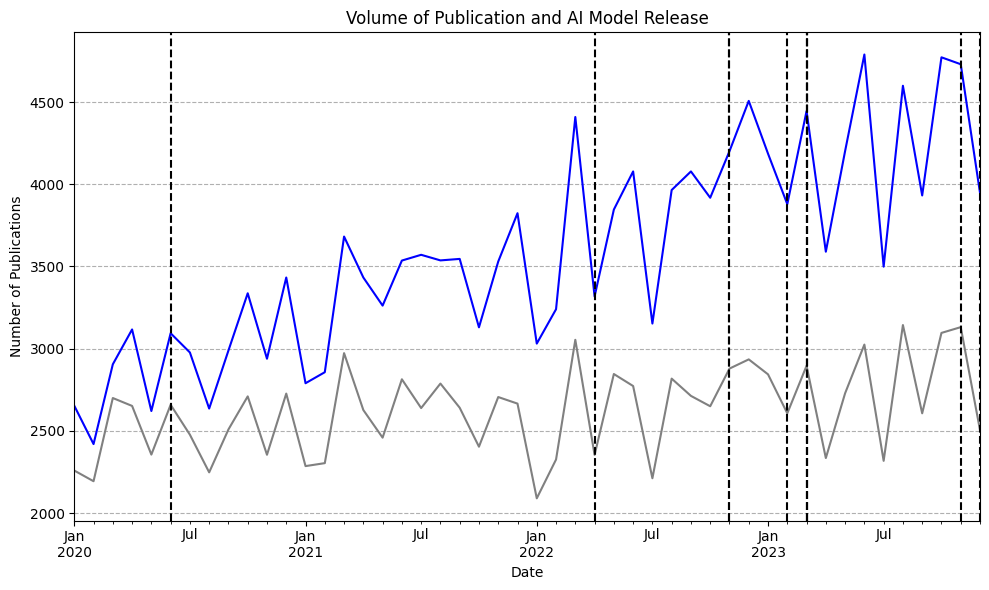

In [74]:
plt.figure(figsize=(10, 6))
ml_per_date.plot(kind='line', color='blue')
nlp_per_date.plot(kind='line', color='gray')

mask = (model_pd['Release Date'] >= '2020-01-05') & (model_pd['Release Date'] < '2023-12-31')

filtered_data = model_pd.loc[mask]

for date in filtered_data['Release Date']:
    plt.axvline(x=date.to_period('M'), color='black', linestyle='--')

plt.title('Volume of Publication and AI Model Release')
plt.xlabel('Date')
plt.ylabel('Number of Publications')
locs, labels = plt.xticks()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()




In [73]:
ml_per_date.to_csv('ml_pb_per_month.csv')
nlp_per_date.to_csv('nlp_pb_per_month.csv')

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

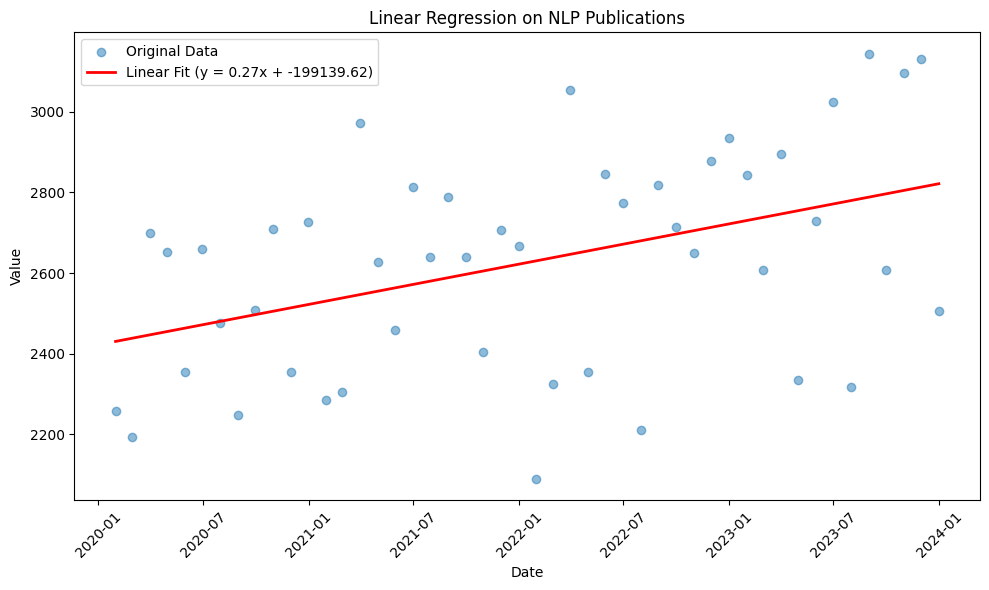

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = nlp_per_date.index
y = nlp_per_date.values

x_numeric = pd.to_datetime(x).map(pd.Timestamp.toordinal)

degree = 1 
coefficients = np.polyfit(x_numeric, y, degree)
polynomial = np.poly1d(coefficients)
linear_fit = polynomial(x_numeric)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Original Data', alpha=0.5)
plt.plot(x, linear_fit, color='red', label=f'Linear Fit (y = {coefficients[0]:.2f}x + {coefficients[1]:.2f})', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Linear Regression on NLP Publications')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


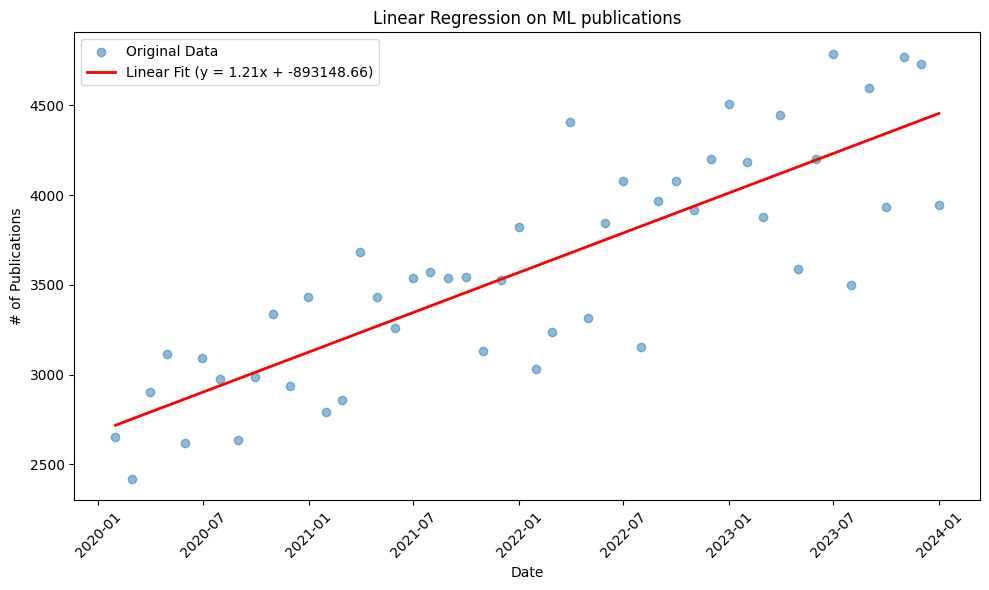

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = ml_per_date.index
y = ml_per_date.values

x_numeric = pd.to_datetime(x).map(pd.Timestamp.toordinal)

degree = 1 
coefficients = np.polyfit(x_numeric, y, degree)
polynomial = np.poly1d(coefficients)
linear_fit = polynomial(x_numeric)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Original Data', alpha=0.5)
plt.plot(x, linear_fit, color='red', label=f'Linear Fit (y = {coefficients[0]:.2f}x + {coefficients[1]:.2f})', linewidth=2)

plt.xlabel('Date')
plt.ylabel('# of Publications')
plt.title('Linear Regression on ML publications')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

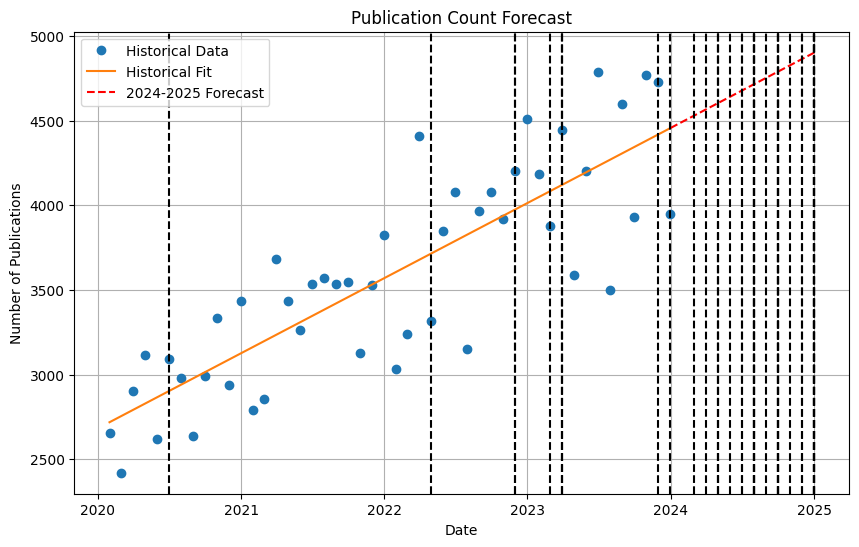

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

x = ml_per_date.index 
y = ml_per_date.values 
x_numeric = pd.to_datetime(x).map(pd.Timestamp.toordinal)

degree = 1 
coefficients = np.polyfit(x_numeric, y, degree) 
polynomial = np.poly1d(coefficients) 

future_dates = pd.date_range(start='2024-01-01', end='2025-01-01', freq='MS')
future_numeric = future_dates.map(pd.Timestamp.toordinal)

future_predictions = polynomial(future_numeric)


plt.figure(figsize=(10, 6))
plt.plot(pd.to_datetime(x), y, 'o', label='Historical Data')
plt.plot(pd.to_datetime(x), polynomial(x_numeric), '-', label='Historical Fit')
plt.plot(future_dates, future_predictions, 'r--', label='2024-2025 Forecast') 
mask = (model_pd['Release Date'] >= '2020-01-05') & (model_pd['Release Date'] < '2025-01-01')

filtered_data = model_pd.loc[mask]

for date in filtered_data['Release Date']:
    plt.axvline(x=date.to_period('M'), color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Number of Publications')
plt.title('Publication Count Forecast')
plt.legend()
plt.grid(True)
plt.show()


